# Online Purchase Prediction Using PyTorch Neural Networks
#### This project develops a neural-network classification model to predict whether an online shopping session will result in a purchase.
#### The project includes data exploration, preprocessing, PyTorch model development, validation-based model selection, hyperparameter tuning, classification-threshold selection, final test evaluation, and comparison with Logistic Regression

In [1]:
# Install the required packages
# !pip install pandas numpy matplotlib scikit-learn torch ucimlrepo optuna

### Import the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import optuna

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report)

np.random.seed(123)
torch.manual_seed(123)

### Load the dataset

In [3]:
data = pd.read_csv('online_shoppers_intention.csv')
data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
# Split data into X(every column except Revenue) and y(Revenue)
X = data.drop(columns=['Revenue'])
y = data['Revenue'].astype(int) # Now it is 0 of Revenue = False; Otherwise, 1

# Basic EDA

In [5]:
# Basic EDA
print(X.describe())

       Administrative  Administrative_Duration  Informational  \
count    12330.000000             12330.000000   12330.000000   
mean         2.315166                80.818611       0.503569   
std          3.321784               176.779107       1.270156   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 7.500000       0.000000   
75%          4.000000                93.256250       0.000000   
max         27.000000              3398.750000      24.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count            12330.000000    12330.000000             12330.000000   
mean                34.472398       31.731468              1194.746220   
std                140.749294       44.475503              1913.669288   
min                  0.000000        0.000000                 0.000000   
25%                  0.000000        7.00000

In [6]:
print(X.isnull().sum()) #There is no null. good

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
dtype: int64


In [7]:
print(y.value_counts(normalize=True)) # we can see only 15 percents of the visit resulted in purchase

Revenue
0    0.845255
1    0.154745
Name: proportion, dtype: float64


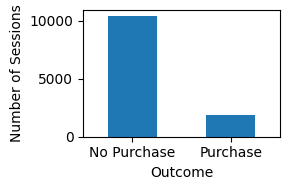

In [8]:
plt.figure(figsize=(3, 2))
y.value_counts().plot(kind="bar")
plt.xlabel("Outcome")
plt.ylabel("Number of Sessions")
plt.xticks([0, 1], ["No Purchase", "Purchase"], rotation=0)
plt.tight_layout()
plt.savefig("purchase_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


# Train / Validation / Test

In [9]:
# We're going to use approximately: 70% training, 15% validation, and 15% testing

from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=123, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=.15/.85, random_state=123, stratify=y_train_val)

print("\nDataset sizes:", "Training:", X_train.shape, "| Validation:", X_val.shape, "| Testing:", X_test.shape)

# I used stratify to keep approximately the same percentage of Revenue = 1 in each split.
print("\nPurchase percentage:", "Training:", y_train.mean().round(3), "| Validation:", y_val.mean().round(3), "| Testing:", y_test.mean().round(3))


Dataset sizes: Training: (8630, 17) | Validation: (1850, 17) | Testing: (1850, 17)

Purchase percentage: Training: 0.155 | Validation: 0.155 | Testing: 0.155


# Data Preprocessing
Neural networks require numerical inputs. Numerical features are standardized
using `StandardScaler`, while categorical features are converted using one-hot
encoding.

The preprocessing transformer is fitted only on the training data to prevent
data leakage.

In [10]:
categorical_columns = ["Month", "OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType", "Weekend"]
numeric_columns = list(X.columns.difference(categorical_columns))

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[("numeric", StandardScaler(), numeric_columns), 
                  ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_columns) ]  )


# To prevent data leakage, I only FIT preprocessing on the training data. However, Validation and test data are only transformed.
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

### Convert Data to PyTorch Tensors & Convert to Datasets

In [11]:
X_train_processed.dtype

dtype('float64')

In [12]:
# It is better to convert it to float32 for PyTorch. We consider it for converting the data to tensors.
# Also, as our processed data is read through pandas, it is better to convert it to numpy, and then into tensors.
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

### Create Dataloaders

In [13]:
# We use Mini-batch Gradient Descent
batch_size = 64
# we want to have a MINI-BATCH training: 64 observations -> prediction -> loss -> gradient -> update weights
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

##### This project is trained on the CPU because the dataset and neural network are relatively small. 
##### PyTorch can also use GPU acceleration (CUDA or MPS) when compatible hardware is available.

# Create Original Neural Network

##### I design a NN that has this structure: 
##### Input features -> 64 neurons -> ReLU -> Dropout 20% -> Dropout -> 32 neurons -> ReLU -> 1 output

In [14]:
class PurchaseNet(nn.Module): # Create my own neural network using PyTorch's NN system (nn.Module).
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64), # Take all input features and connect them to 64 neurons.
            nn.ReLU(), # the activation function of max(0,a)
            nn.Dropout(0.20), # Helps reduce overfitting during training
            nn.Linear(64, 32), # Take the information from those 64 neurons and pass it to 32 neurons.
            nn.ReLU(),
            nn.Linear(32, 1) # Produce one final number. Note that az we use ReLU, it is not a probability.
        )

    def forward(self, x):
        return self.network(x).squeeze(1)

input_size = X_train_processed.shape[1]
model = PurchaseNet(input_size = input_size)
print(model)

PurchaseNet(
  (network): Sequential(
    (0): Linear(in_features=73, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)


### Loss Function

In [15]:
# I use BCEWithLogitsLoss as it combines Sigmoid + Binary Cross Entropy
criterion = nn.BCEWithLogitsLoss()

### Optimizer

In [16]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) #Adam decides HOW to change the weights using the gradients calculated during backpropagation.

## Train & Validate the NN

#### ONE IMPORTANT NOTE:

##### The number of epochs is important because training a neural network for too long can cause overfitting.
##### We use the validation set to monitor whether the model is still generalizing well to unseen data.

##### I initially tested a larger number of epochs and observed overfitting.
##### Validation loss suggested that approximately 7 epochs was appropriate for the original model.

In [17]:
epochs = 7
train_losses = []
val_losses = []

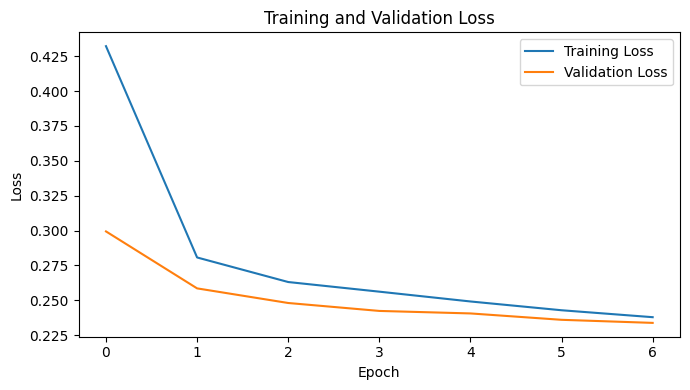

In [18]:
# Now, we want to implement whatever we defined above: 
# 1. Predict -> 2. Calculate loss -> 3. Set gradients zero -> 4. Backpropagation -> 5. Update Weights
for epoch in range(epochs):
    ## Training 
    model.train()
    total_train_loss = 0
    for X_batch, y_batch in train_loader:
        # 1. Predict
        logits = model(X_batch)
        
        # 2. Calculate loss
        loss = criterion(logits, y_batch)

        # 3. Set gradients zero
        optimizer.zero_grad()

        # 4. Backpropagation (Calculate gradients)
        loss.backward()

        # 5. Update Weights
        optimizer.step()

        total_train_loss += loss.item()


    average_train_loss = (total_train_loss / len(train_loader))
    train_losses.append(average_train_loss)

    ## Validation
    model.eval()
    total_val_loss = 0
    
    with torch.no_grad(): # No gradients needed during validation
        for X_batch, y_batch in val_loader:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_val_loss += loss.item()

    average_val_loss = (total_val_loss/ len(val_loader))
    val_losses.append(average_val_loss)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("training_validation_loss.png")
plt.show()


# Original Neural Network: Validation Predictions

In [19]:
# Now, I use the validation set to choose the classification threshold.
model.eval() # Put the model in evaluation mode
val_probabilities = []
val_true_labels = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        logits = model(X_batch) # Get the raw output (logits)
        probabilities = torch.sigmoid(logits) # Convert logits to probabilities between 0 and 1
        val_probabilities.extend(probabilities.numpy())
        val_true_labels.extend(y_batch.numpy())

# Convert lists to NumPy arrays
val_probabilities = np.array(val_probabilities)
val_true_labels = np.array(val_true_labels)

#### Original Neural Network: Select Best Threshold

In [20]:
# We try different thresholds and select the one with the highest validation F1 score
thresholds = np.arange(0.10, 0.91, 0.05)
best_threshold = 0
best_f1 = 0

for threshold in thresholds:
    val_predictions = (val_probabilities >= threshold).astype(int)
    f1 = f1_score(val_true_labels, val_predictions)
    print(f"Threshold: {threshold:.2f} | " f"F1 Score: {f1:.3f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("\nBest threshold:", round(best_threshold, 2))

Threshold: 0.10 | F1 Score: 0.576
Threshold: 0.15 | F1 Score: 0.637
Threshold: 0.20 | F1 Score: 0.660
Threshold: 0.25 | F1 Score: 0.673
Threshold: 0.30 | F1 Score: 0.671
Threshold: 0.35 | F1 Score: 0.678
Threshold: 0.40 | F1 Score: 0.669
Threshold: 0.45 | F1 Score: 0.665
Threshold: 0.50 | F1 Score: 0.660
Threshold: 0.55 | F1 Score: 0.638
Threshold: 0.60 | F1 Score: 0.621
Threshold: 0.65 | F1 Score: 0.573
Threshold: 0.70 | F1 Score: 0.536
Threshold: 0.75 | F1 Score: 0.452
Threshold: 0.80 | F1 Score: 0.311
Threshold: 0.85 | F1 Score: 0.210
Threshold: 0.90 | F1 Score: 0.048

Best threshold: 0.35


# HYPERPARAMETER TUNING WITH OPTUNA

#### This model is similar to the original neural network, but its hyperparameters can be changed by Optuna.

In [21]:
class TunedPurchaseNet(nn.Module):
    def __init__(self, input_size, hidden1, hidden2, dropout):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)

### Reusable Training Function for Optuna

In [22]:
def train_nn(model, train_loader, epochs, learning_rate, weight_decay):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    for epoch in range(epochs):
        model.train()

        for X_batch, y_batch in train_loader:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return model

### Function to Generate Probabilities

In [23]:
def get_probabilities(model, data_loader):
    model.eval()
    probabilities = []
    true_labels = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            logits = model(X_batch)
            probs = torch.sigmoid(logits)
            probabilities.extend(probs.numpy())
            true_labels.extend(y_batch.numpy())

    return np.array(probabilities), np.array(true_labels)

### Function to Find Best Classification Threshold

In [24]:
def find_best_threshold(y_true, probabilities):
    thresholds = np.arange(0.10, 0.91, 0.05)
    best_threshold = 0
    best_f1 = 0

    for threshold in thresholds:
        predictions = (probabilities >= threshold).astype(int)
        current_f1 = f1_score(y_true, predictions)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = threshold

    return best_threshold, best_f1

### Optuna Objective Function

In [25]:
def objective(trial):
    
    # Reset random seeds so trials are more comparable
    np.random.seed(123)
    torch.manual_seed(123)

    # Hyperparameters that Optuna will search
    hidden1 = trial.suggest_categorical("hidden1", [32, 64, 128])
    hidden2 = trial.suggest_categorical("hidden2", [16, 32, 64])
    dropout = trial.suggest_float("dropout", 0.0, 0.5, step=0.1)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 5e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    epochs = trial.suggest_int("epochs", 5, 20)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

    # Training DataLoader for this trial
    generator = torch.Generator().manual_seed(123)
    trial_train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=generator)

    # Create neural network using the hyperparameters suggested by Optuna
    model_trial = TunedPurchaseNet(input_size=X_train_processed.shape[1], hidden1=hidden1, hidden2=hidden2, dropout=dropout)

    # Train the model
    model_trial = train_nn(model_trial, trial_train_loader, epochs, learning_rate, weight_decay)

    # Evaluate only on validation data
    val_probabilities_trial, val_labels_trial = get_probabilities(model_trial, val_loader)

    # Find threshold that maximizes validation F1
    best_threshold_trial, validation_f1 = find_best_threshold(val_labels_trial, val_probabilities_trial)

    # Save the best threshold for this trial
    trial.set_user_attr("best_threshold", float(best_threshold_trial))

    return validation_f1

### Run Optuna

In [26]:
sampler = optuna.samplers.TPESampler(seed=123)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=30);

[I 2026-08-19 08:30:39,896] A new study created in memory with name: no-name-adcf0cdc-009a-488b-9f83-8de9c363007c
[I 2026-08-19 08:30:41,733] Trial 0 finished with value: 0.673469387755102 and parameters: {'hidden1': 32, 'hidden2': 32, 'dropout': 0.5, 'learning_rate': 0.0014571530978569832, 'batch_size': 32, 'epochs': 16, 'weight_decay': 5.679223741740075e-05}. Best is trial 0 with value: 0.673469387755102.
[I 2026-08-19 08:30:43,939] Trial 1 finished with value: 0.6655518394648829 and parameters: {'hidden1': 128, 'hidden2': 64, 'dropout': 0.30000000000000004, 'learning_rate': 0.001196267211457031, 'batch_size': 32, 'epochs': 16, 'weight_decay': 1.958103552839225e-05}. Best is trial 0 with value: 0.673469387755102.
[I 2026-08-19 08:30:44,736] Trial 2 finished with value: 0.6740157480314961 and parameters: {'hidden1': 32, 'hidden2': 16, 'dropout': 0.2, 'learning_rate': 0.0006898523888022902, 'batch_size': 128, 'epochs': 19, 'weight_decay': 0.005979158591419456}. Best is trial 2 with val

# Best Optuna Results

In [27]:
print("\nBest Validation F1:", round(study.best_value, 3))
print("\nBest Hyperparameters:")
print(study.best_params)
print("\nThreshold from Best Optuna Trial:", study.best_trial.user_attrs["best_threshold"])


Best Validation F1: 0.684

Best Hyperparameters:
{'hidden1': 64, 'hidden2': 64, 'dropout': 0.30000000000000004, 'learning_rate': 0.0019290964373014923, 'batch_size': 64, 'epochs': 12, 'weight_decay': 0.001152332952567702}

Threshold from Best Optuna Trial: 0.30000000000000004


##### The tuned model selected 12 epochs as optimal, whereas the earlier standalone analysis suggested 7 epochs for the original neural network. This difference occurs because the earlier analysis varied the number of epochs while keeping the other hyperparameters fixed. Optuna instead optimizes the number of epochs jointly with the network architecture, dropout, learning rate, batch size, and weight decay. Therefore, 12 epochs is optimal for this specific combination of tuned hyperparameters, while 7 epochs was appropriate for the original model configuration.

### Train Final Tuned Neural Network

In [28]:
best_params = study.best_params
np.random.seed(123)
torch.manual_seed(123)
tuned_generator = torch.Generator().manual_seed(123)
tuned_train_loader = DataLoader(train_dataset, batch_size=best_params["batch_size"], shuffle=True, generator=tuned_generator)
tuned_model = TunedPurchaseNet(input_size=X_train_processed.shape[1], hidden1=best_params["hidden1"], hidden2=best_params["hidden2"], dropout=best_params["dropout"])
tuned_model = train_nn(tuned_model, tuned_train_loader, best_params["epochs"], best_params["learning_rate"], best_params["weight_decay"])

In [29]:
tuned_val_probabilities, tuned_val_true_labels = get_probabilities(tuned_model, val_loader)
tuned_threshold, tuned_validation_f1 = find_best_threshold(tuned_val_true_labels, tuned_val_probabilities)

print("\nTuned NN Best Threshold:", round(tuned_threshold, 2))
print("Tuned NN Validation F1:", round(tuned_validation_f1, 3))


Tuned NN Best Threshold: 0.3
Tuned NN Validation F1: 0.684


# Logistic Regression Baseline

In [30]:
# Train only on training data
from sklearn.linear_model import LogisticRegression
baseline_model = LogisticRegression(max_iter=2000, class_weight="balanced")
baseline_model.fit(X_train_processed, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000)

# Final Evaluation on the Test Set

### Test Predictions

In [31]:
# Original Neural Network
original_test_probabilities, original_test_true_labels = get_probabilities(model, test_loader)
original_test_predictions = (original_test_probabilities >= best_threshold).astype(int)

# Tuned Neural Network Test Predictions
tuned_test_probabilities, tuned_test_true_labels = get_probabilities(tuned_model, test_loader)
tuned_test_predictions = (tuned_test_probabilities >= tuned_threshold).astype(int)

# Logistic Regression Test Predictions
baseline_probabilities = baseline_model.predict_proba(X_test_processed)[:, 1]
baseline_predictions = (baseline_probabilities >= 0.50).astype(int)

### Calculate Metrics for All Three Models

In [32]:
def calculate_metrics(y_true, probabilities, predictions):
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1 Score": f1_score(y_true, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probabilities),
        "PR-AUC": average_precision_score(y_true, probabilities)
    }

original_nn_metrics = calculate_metrics(original_test_true_labels, original_test_probabilities, original_test_predictions)
tuned_nn_metrics = calculate_metrics(tuned_test_true_labels, tuned_test_probabilities, tuned_test_predictions)
logistic_metrics = calculate_metrics(y_test.to_numpy(), baseline_probabilities, baseline_predictions)

In [33]:
print("\nOriginal Neural Network Results:")
print(f"Accuracy:  {original_nn_metrics['Accuracy']:.3f}")
print(f"Precision: {original_nn_metrics['Precision']:.3f}")
print(f"Recall:    {original_nn_metrics['Recall']:.3f}")
print(f"F1 Score:  {original_nn_metrics['F1 Score']:.3f}")
print(f"ROC-AUC:   {original_nn_metrics['ROC-AUC']:.3f}")
print(f"PR-AUC:    {original_nn_metrics['PR-AUC']:.3f}")

print("\nOptuna-Tuned Neural Network Results:")
print(f"Accuracy:  {tuned_nn_metrics['Accuracy']:.3f}")
print(f"Precision: {tuned_nn_metrics['Precision']:.3f}")
print(f"Recall:    {tuned_nn_metrics['Recall']:.3f}")
print(f"F1 Score:  {tuned_nn_metrics['F1 Score']:.3f}")
print(f"ROC-AUC:   {tuned_nn_metrics['ROC-AUC']:.3f}")
print(f"PR-AUC:    {tuned_nn_metrics['PR-AUC']:.3f}")

print("\nLogistic Regression Results:")
print(f"Accuracy:  {logistic_metrics['Accuracy']:.3f}")
print(f"Precision: {logistic_metrics['Precision']:.3f}")
print(f"Recall:    {logistic_metrics['Recall']:.3f}")
print(f"F1 Score:  {logistic_metrics['F1 Score']:.3f}")
print(f"ROC-AUC:   {logistic_metrics['ROC-AUC']:.3f}")
print(f"PR-AUC:    {logistic_metrics['PR-AUC']:.3f}")


Original Neural Network Results:
Accuracy:  0.890
Precision: 0.630
Recall:    0.703
F1 Score:  0.664
ROC-AUC:   0.917
PR-AUC:    0.725

Optuna-Tuned Neural Network Results:
Accuracy:  0.895
Precision: 0.641
Recall:    0.731
F1 Score:  0.683
ROC-AUC:   0.923
PR-AUC:    0.735

Logistic Regression Results:
Accuracy:  0.845
Precision: 0.500
Recall:    0.766
F1 Score:  0.605
ROC-AUC:   0.896
PR-AUC:    0.648


# Compare All Three Models

In [34]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Original Neural Network", "Optuna-Tuned Neural Network"],
    "Accuracy": [logistic_metrics["Accuracy"], original_nn_metrics["Accuracy"], tuned_nn_metrics["Accuracy"]],
    "Precision": [logistic_metrics["Precision"], original_nn_metrics["Precision"], tuned_nn_metrics["Precision"]],
    "Recall": [logistic_metrics["Recall"], original_nn_metrics["Recall"], tuned_nn_metrics["Recall"]],
    "F1 Score": [logistic_metrics["F1 Score"], original_nn_metrics["F1 Score"], tuned_nn_metrics["F1 Score"]],
    "ROC-AUC": [logistic_metrics["ROC-AUC"], original_nn_metrics["ROC-AUC"], tuned_nn_metrics["ROC-AUC"]],
    "PR-AUC": [logistic_metrics["PR-AUC"], original_nn_metrics["PR-AUC"], tuned_nn_metrics["PR-AUC"]]
})

print("\nModel Comparison:")
print(results.round(3))


Model Comparison:
                         Model  Accuracy  Precision  Recall  F1 Score  \
0          Logistic Regression     0.845      0.500   0.766     0.605   
1      Original Neural Network     0.890      0.630   0.703     0.664   
2  Optuna-Tuned Neural Network     0.895      0.641   0.731     0.683   

   ROC-AUC  PR-AUC  
0    0.896   0.648  
1    0.917   0.725  
2    0.923   0.735  


### Confusion Matrix - Original Neural Network

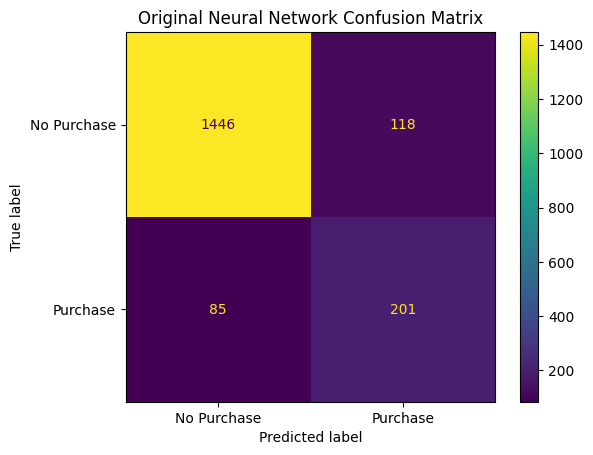

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
confusion = confusion_matrix(original_test_true_labels, original_test_predictions)
display = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=["No Purchase", "Purchase"])
display.plot()
plt.title("Original Neural Network Confusion Matrix")
plt.show()

### Confusion Matrix - Optuna-Tuned Neural Network

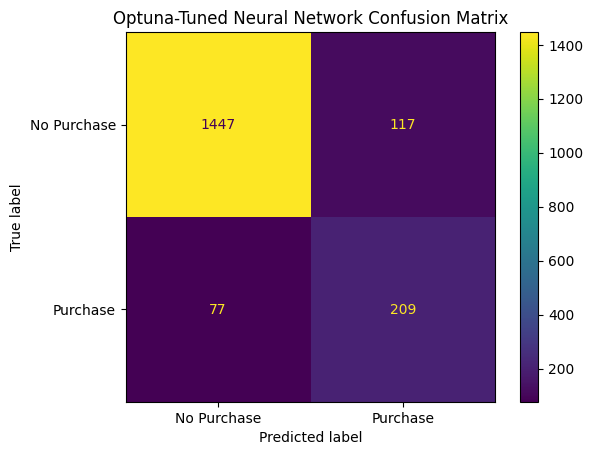

In [36]:
confusion_tuned = confusion_matrix(tuned_test_true_labels, tuned_test_predictions)
display_tuned = ConfusionMatrixDisplay(confusion_matrix=confusion_tuned, display_labels=["No Purchase", "Purchase"])
display_tuned.plot()
plt.title("Optuna-Tuned Neural Network Confusion Matrix")
plt.show()

### Model Performance Comparison Plot

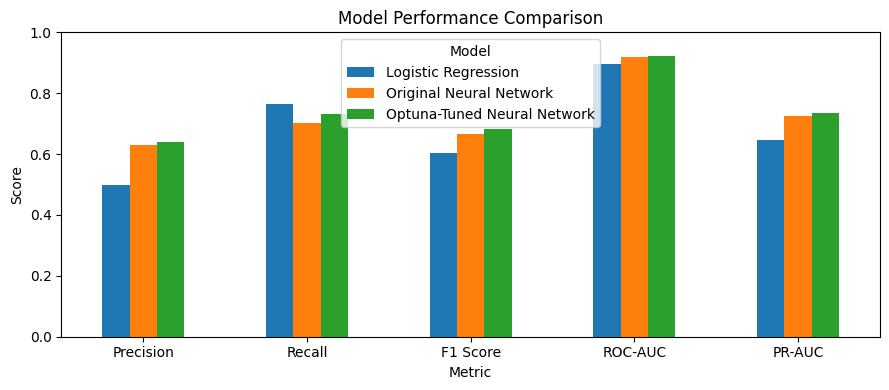

In [37]:
comparison_plot = results.set_index("Model")[["Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"]]
comparison_plot.T.plot(kind="bar", figsize=(9, 4))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.savefig("model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Optional Optuna Visualizations

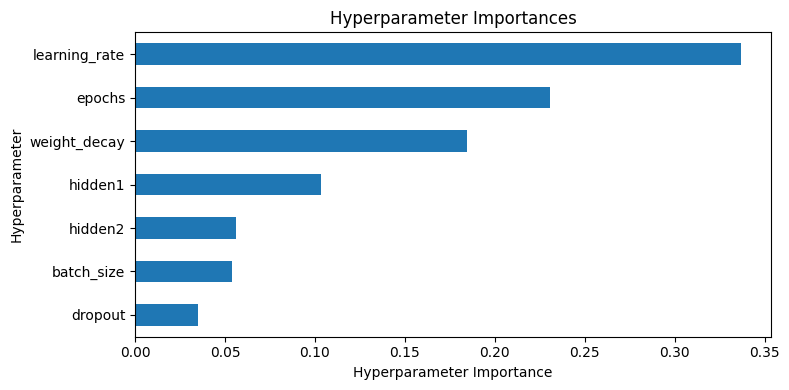

In [38]:
import optuna.importance

importances = optuna.importance.get_param_importances(study)

plt.figure(figsize=(8, 4))
pd.Series(importances).sort_values().plot(kind="barh")
plt.xlabel("Hyperparameter Importance")
plt.ylabel("Hyperparameter")
plt.title("Hyperparameter Importances")
plt.tight_layout()
plt.savefig("hyperparameter_importances.png", dpi=300, bbox_inches="tight")
plt.show()